In [18]:
import numpy as np
import pylab as plt
import pandas as pd

from matplotlib.patches import FancyBboxPatch
from astropy.visualization import quantity_support
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x76de41272f90>

In [19]:
## load in the data, created using prep_csv.py
#infile_name = '/home/ellie/research/lsst/s1003Hmna_data_vel_poli.csv'
infile_name = '/home/ellie/research/lsst/mpcorb_ceres_vel_new.csv' #22aug.csv' #S100a6n8a_data_vel.csv'
infile_name_poli = '/home/ellie/research/lsst/mpcorb_ceres_vel_new_poli.csv' #22aug_poli.csv' #S100a6n8a_data_vel_poli.csv'

df = pd.read_csv(infile_name)
df_poli = pd.read_csv(infile_name_poli)

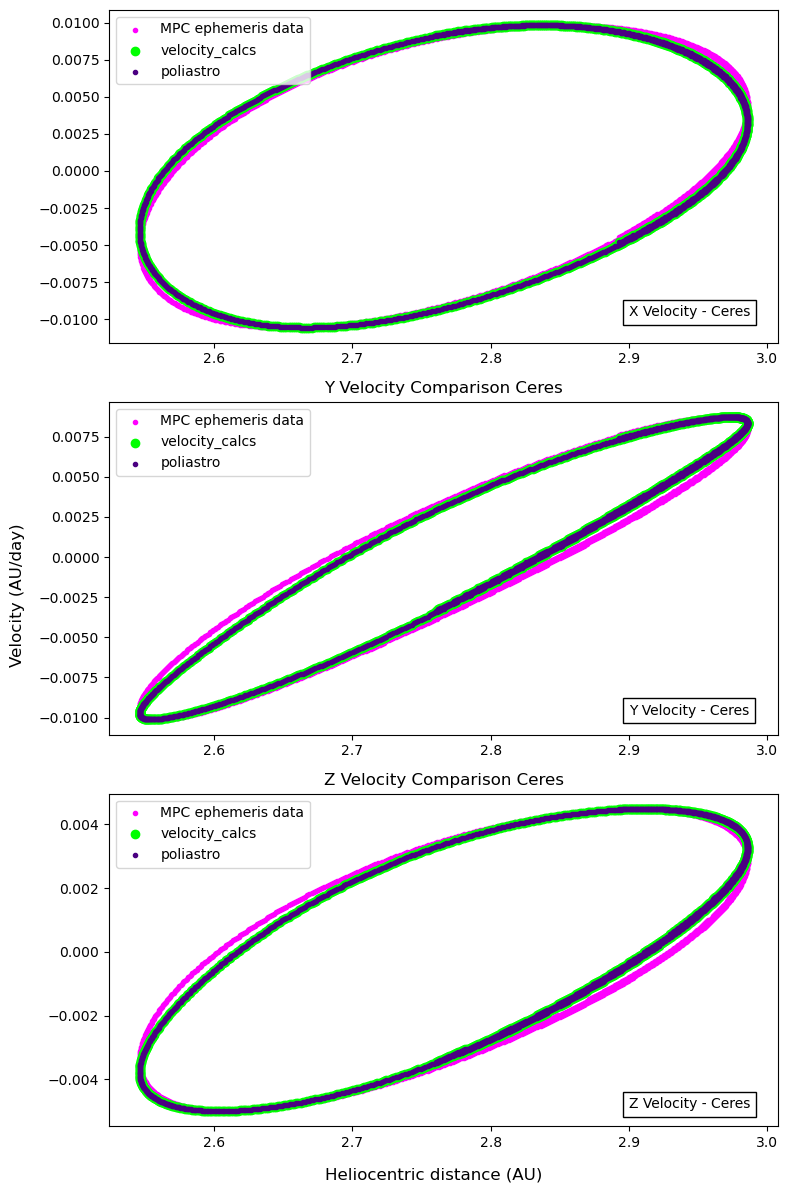

In [31]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)

ax1.scatter(df['heliocentricDist'], df["X'"], marker='.', label='MPC ephemeris data', c='fuchsia')
ax1.scatter(df['heliocentricDist'], df['x_dotk'], label='velocity_calcs', c='lime')
ax1.scatter(df_poli['heliocentricDist'], df_poli['x_dotk'], marker='.', label='poliastro', c='indigo')

#plt.scatter(df['heliocentricDist'], df['heliocentricVX'], marker='.', label='measured')
#ax1.set_title('X Velocity Comparison Ceres')
ax1.text(2.90, -0.01, 'X Velocity - Ceres', verticalalignment='bottom', bbox=dict(linewidth=1, facecolor='white'))
ax1.legend(loc='upper left')

ax2.scatter(df['heliocentricDist'], df["Y'"], marker='.', label='MPC ephemeris data', c='fuchsia')
ax2.scatter(df['heliocentricDist'], df['y_dotk'], label='velocity_calcs', c='lime') #df['y_dotk'], marker='.', label='kepler')
#plt.scatter(df['r'], df['heliocentricVY'], marker='.', label='measured')
ax2.scatter(df_poli['heliocentricDist'], df_poli['y_dotk'], marker='.', label='poliastro', c='indigo')
ax2.set_title('Y Velocity Comparison Ceres')
ax2.legend(loc='upper left')
ax2.text(2.90, -0.01, 'Y Velocity - Ceres', verticalalignment='bottom', bbox=dict(linewidth=1, facecolor='white'))

ax3.scatter(df['heliocentricDist'], df["Z'"], marker='.', label='MPC ephemeris data', c='fuchsia')
ax3.scatter(df['heliocentricDist'], df['z_dotk'], label='velocity_calcs', c='lime')
#plt.scatter(df['r'], df['heliocentricVZ'], marker='.', label='measured')
ax3.scatter(df_poli['heliocentricDist'], df_poli['z_dotk'], marker='.', label='poliastro', c='indigo')
ax3.set_title('Z Velocity Comparison Ceres')
ax3.legend()
ax3.text(2.90, -0.005, 'Z Velocity - Ceres', verticalalignment='bottom', bbox=dict(linewidth=1, facecolor='white'))

fig.supxlabel('Heliocentric distance (AU)', x=0.55)
fig.supylabel('Velocity (AU/day)')

fig.set_figwidth(8)
fig.set_figheight(12)
plt.tight_layout()
plt.savefig('/home/ellie/research/lsst/velocity_ceres_new.png', dpi=300)
plt.show()


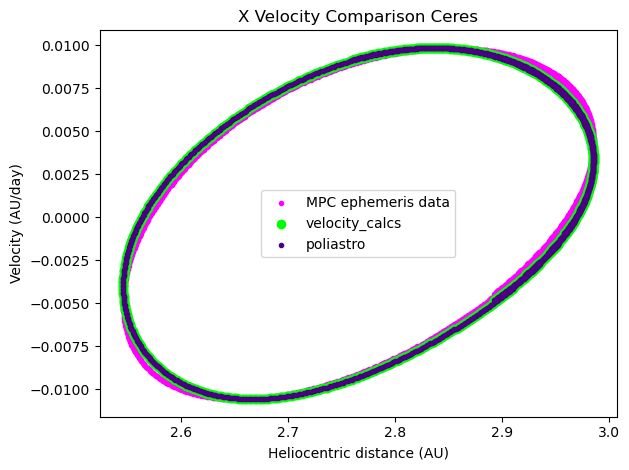

In [3]:
#plt.scatter(df['r'], df['x_dotk']-df_poli['x_dotk'], marker='.', label='kepler')

plt.scatter(df['heliocentricDist'], df["X'"], marker='.', label='MPC ephemeris data', c='fuchsia')
plt.scatter(df['heliocentricDist'], df['x_dotk'], label='velocity_calcs', c='lime')
plt.scatter(df_poli['heliocentricDist'], df_poli['x_dotk'], marker='.', label='poliastro', c='indigo')

#plt.scatter(df['heliocentricDist'], df['heliocentricVX'], marker='.', label='measured')
plt.title('X Velocity Comparison Ceres')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.tight_layout()
plt.savefig('/home/ellie/research/lsst/xvelocity_ceres_new.png', dpi=300)
plt.show()

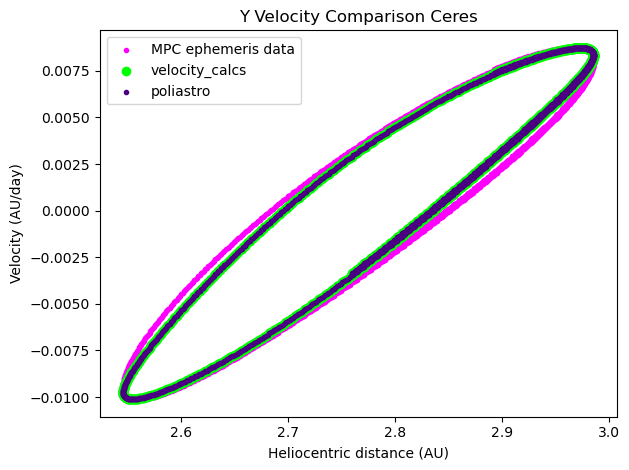

In [4]:
## convert poliastro data from ecliptic to j2000
#eps = np.radians(23.43928)
#vy = np.cos(eps)*df_poli['y_dotk'] - np.sin(eps)*df_poli['z_dotk']

## plot the velocities overlaid on each other

plt.scatter(df['heliocentricDist'], df["Y'"], marker='.', label='MPC ephemeris data', c='fuchsia')
plt.scatter(df['heliocentricDist'], df['y_dotk'], label='velocity_calcs', c='lime') #df['y_dotk'], marker='.', label='kepler')
#plt.scatter(df['r'], df['heliocentricVY'], marker='.', label='measured')
plt.scatter(df_poli['heliocentricDist'], df_poli['y_dotk'], marker='.', label='poliastro', c='indigo')
plt.title('Y Velocity Comparison Ceres')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.tight_layout()
plt.savefig('/home/ellie/research/lsst/yvelocity_ceres_new.png', dpi=300)
plt.show()

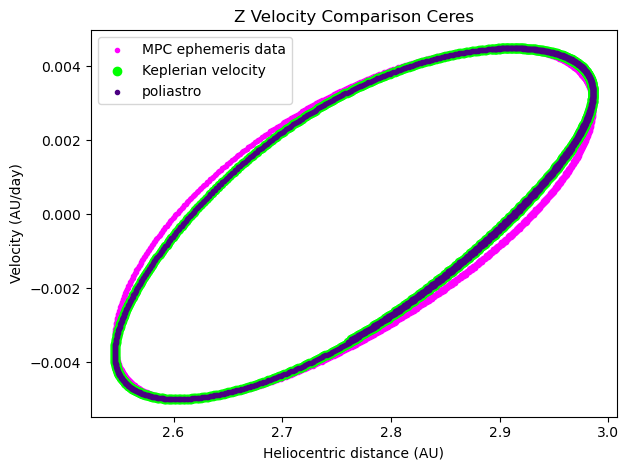

In [5]:
## convert poliastro data from ecliptic to j2000
eps = np.radians(23.43928)
#vz = np.sin(eps)*df_poli['y_dotk'] + np.cos(eps)*df_poli['z_dotk'] #-Y_dot*np.sin(i) #v_xyz[2]

## plot the velocities overlaid on each other

plt.scatter(df['heliocentricDist'], df["Z'"], marker='.', label='MPC ephemeris data', c='fuchsia')
plt.scatter(df['heliocentricDist'], df['z_dotk'], label='Keplerian velocity', c='lime')
#plt.scatter(df['r'], df['heliocentricVZ'], marker='.', label='measured')
plt.scatter(df_poli['heliocentricDist'], df_poli['z_dotk'], marker='.', label='poliastro', c='indigo')
plt.title('Z Velocity Comparison Ceres')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.tight_layout()
plt.savefig('/home/ellie/research/lsst/zvelocity_ceres_new.png', dpi=300)
plt.show()

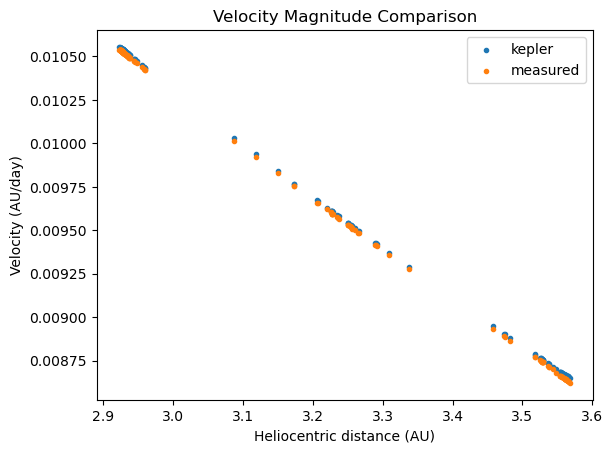

In [26]:
## plot the velocities overlaid on each other

## first, plot the Keplerian and "measured"
## velocity magnitudes for comparison

plt.scatter(df['r'], df['vk'], marker='.', label='kepler')
plt.scatter(df['r'], df['v'], marker='.', label='measured')
plt.title('Velocity Magnitude Comparison')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.show()

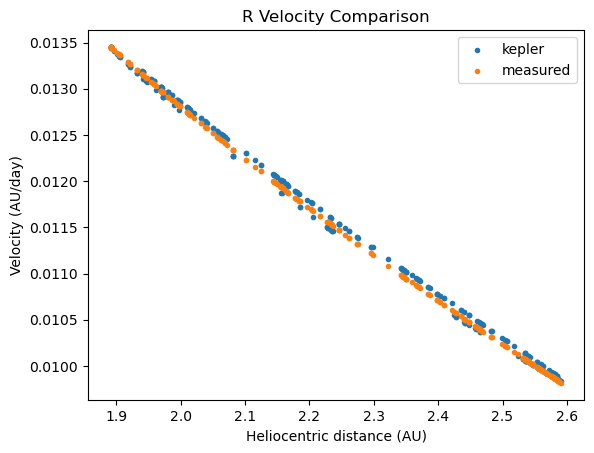

In [267]:
## plot the velocities overlaid on each other

plt.scatter(df['r'], df['r_dotk'], marker='.', label='kepler')
plt.scatter(df['r'], df['r_dot'], marker='.', label='measured')
plt.title('R Velocity Comparison')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.savefig('/home/ellie/research/lsst/rvelocity.png')
plt.show()

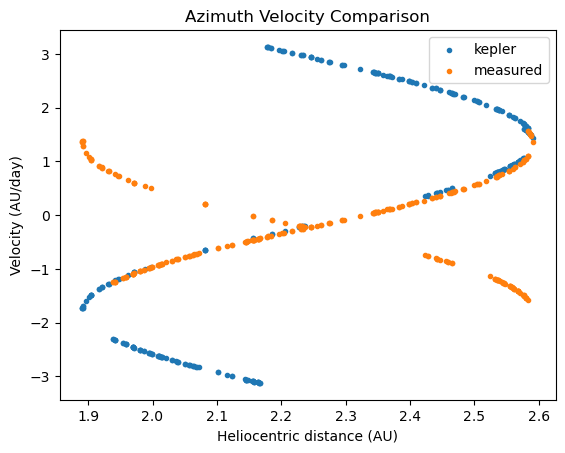

In [268]:
## plot the velocities overlaid on each other

plt.scatter(df['r'], df['az_dotk'], marker='.', label='kepler')
plt.scatter(df['r'], df['az_dot'], marker='.', label='measured')
plt.title('Azimuth Velocity Comparison')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.savefig('/home/ellie/research/lsst/azvelocity.png')
plt.show()

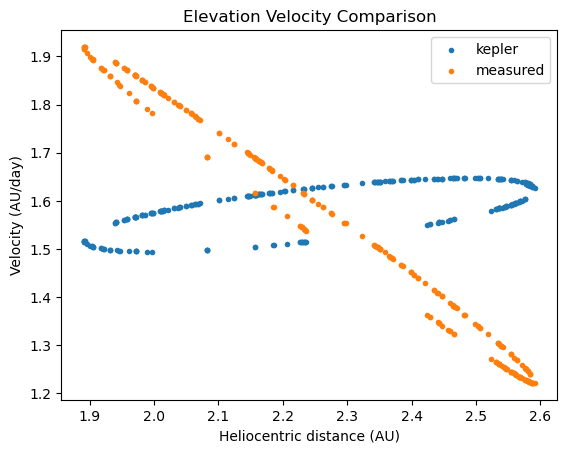

In [269]:
## plot the velocities overlaid on each other

plt.scatter(df['r'], df['el_dotk'], marker='.', label='kepler')
plt.scatter(df['r'], df['el_dot'], marker='.', label='measured')
plt.title('Elevation Velocity Comparison')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.savefig('/home/ellie/research/lsst/elvelocity.png')
plt.show()

In [250]:
## plot my calculations vs poliastro
## load in the data, created using prep_csv.py
infile_name1 = '/home/ellie/research/lsst/s1003Hmna_data_vel.csv'
infile_name2 = '/home/ellie/research/lsst/s1003Hmna_data_vel_poli.csv'
#infile_name = '/home/ellie/research/lsst/S100a6n8a_data_vel.csv'
df1 = pd.read_csv(infile_name1)
df2 = pd.read_csv(infile_name2)

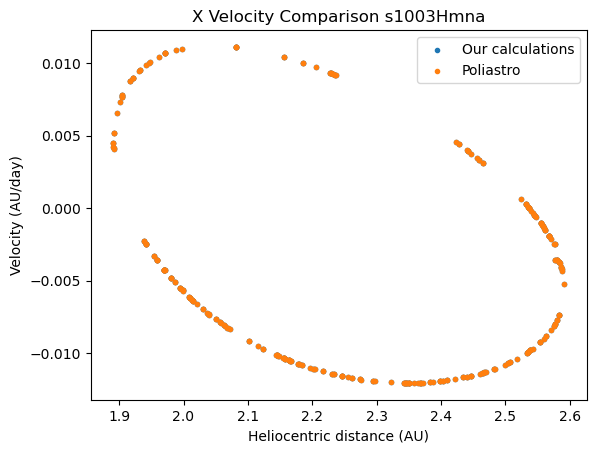

In [260]:
plt.scatter(df1['r'], df1['x_dotk'], marker='.', label='Our calculations')
plt.scatter(df1['r'], df2['x_dotk'], marker='.', label='Poliastro')
plt.title('X Velocity Comparison s1003Hmna')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.savefig('/home/ellie/research/lsst/xvelocity_s1003Hmna_poli.png')
plt.show()

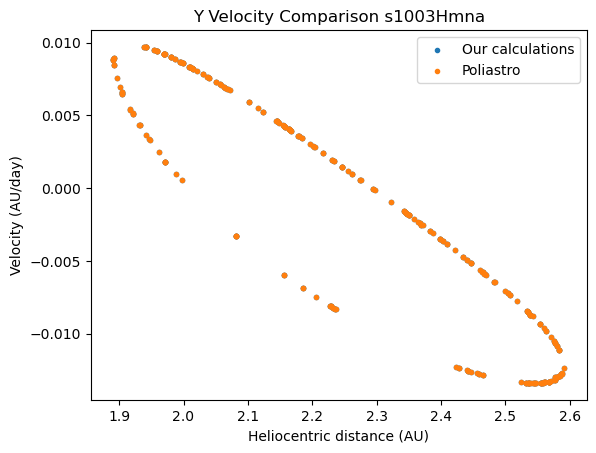

In [261]:
plt.scatter(df1['r'], df1['y_dotk'], marker='.', label='Our calculations')
plt.scatter(df1['r'], df2['y_dotk'], marker='.', label='Poliastro')
plt.title('Y Velocity Comparison s1003Hmna')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.savefig('/home/ellie/research/lsst/yvelocity_s1003Hmna_poli.png')
plt.show()

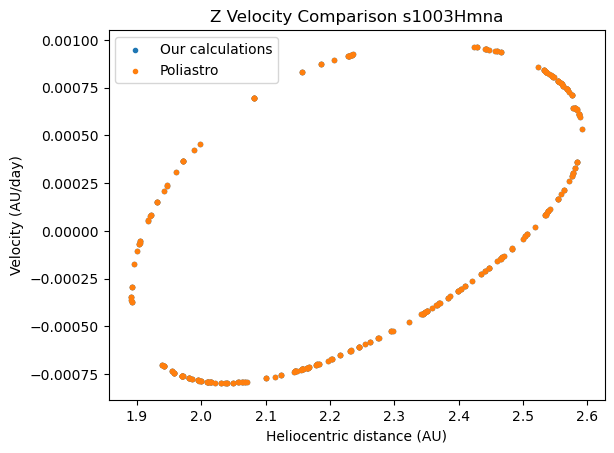

In [262]:
plt.scatter(df1['r'], df1['z_dotk'], marker='.', label='Our calculations')
plt.scatter(df1['r'], df2['z_dotk'], marker='.', label='Poliastro')
plt.title('Z Velocity Comparison s1003Hmna')
plt.legend()

plt.xlabel('Heliocentric distance (AU)')
plt.ylabel('Velocity (AU/day)')
plt.savefig('/home/ellie/research/lsst/zvelocity_s1003Hmna_poli.png')
plt.show()